# Evolutionary Timeline (CCF density) -- SJOS001115_D1 and SA541936 

Minimal, self-contained pipeline that goes from raw SVClone output to the per-sample CCF-density figure, restricted to samples: `SJOS001115_D1` and `SA541936`.

## 0. Imports and target samples

In [1]:
import os
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# The only two samples this notebook will ever load or plot.
TARGET_SAMPLES = ['SJOS001115_D1', 'SA541936']

## 1. Load Terra table, restrict to target samples

List is directly filtered down to the two target samples for quicker computational performance.

In [2]:
terra_table = pd.read_csv('../../../SV_Clone/SV_Clone_Samples_id_terra_table.tsv', sep='\t')

if 'postassign_cluster_results' in terra_table.columns:
    terra_table['target_tar'] = terra_table['postassign_cluster_results'].fillna(terra_table['svclone_final_tar'])
else:
    terra_table['target_tar'] = terra_table['svclone_final_tar']

df_terralinks = terra_table[terra_table['target_tar'].notna()].copy()
df_terralinks = df_terralinks.rename(columns={"entity:SV_Clone_Samples_id": "Samples"})

df_terralinks = df_terralinks[df_terralinks['Samples'].isin(TARGET_SAMPLES)].copy()
print(f"Samples found in Terra table: {sorted(df_terralinks['Samples'].unique())}")
assert set(df_terralinks['Samples']) == set(TARGET_SAMPLES), \
    f"Missing from Terra table: {set(TARGET_SAMPLES) - set(df_terralinks['Samples'])}"

Samples found in Terra table: ['SA541936', 'SJOS001115_D1']


## 2. Load and process SV/SNV subclonal structure for these 2 samples

In [ ]:
def process_variants(structure_df, certainty_df, variant_type, sample, purity):
    structure_df = structure_df.copy()
    structure_df['CCF'] = structure_df['proportion'] / purity
    structure_df['Clonality_Status'] = structure_df['CCF'].apply(
        lambda x: 'Early_Clonal' if x >= 0.9 else 'Subclonal'
    )

    merged_df = certainty_df.merge(
        structure_df[['cluster', 'CCF', 'Clonality_Status']],
        left_on='most_likely_assignment',
        right_on='cluster',
        how='left'
    )
    merged_df['Variant_Type'] = variant_type
    merged_df['Sample_ID'] = sample
    return merged_df.drop(columns=['cluster'])

In [12]:
base_dir = '/Users/thorsten/Postdoc/Osteosarcoma_wgs_shreya/Data/SV_Clone/SVClone_Output'
master_file = []

for _, row in df_terralinks.iterrows():
    sample = row['Samples']
    purity = row['purity']

    print(f"Processing {sample}...")

    sample_dir = os.path.join(base_dir, sample)
    post_assign_dir = os.path.join(sample_dir, "ccube_out", "post_assign")
    ccube_out_dir = os.path.join(sample_dir, "ccube_out")

    if os.path.exists(post_assign_dir):
        sv_dir = post_assign_dir
        snv_dir = os.path.join(post_assign_dir, "snvs")
    else:
        sv_dir = ccube_out_dir
        snv_dir = os.path.join(ccube_out_dir, "snvs")

    try:
        sv_structure_file = pd.read_csv(os.path.join(sv_dir, f'{sample}_subclonal_structure.txt'), sep='\t')
        sv_certainty_file = pd.read_csv(os.path.join(sv_dir, f'{sample}_cluster_certainty.txt'), sep='\t')

        snv_structure_file = pd.read_csv(os.path.join(snv_dir, f'{sample}_subclonal_structure.txt'), sep='\t')
        snv_certainty_file = pd.read_csv(os.path.join(snv_dir, f'{sample}_cluster_certainty.txt'), sep='\t')

        sv_processed = process_variants(sv_structure_file, sv_certainty_file, 'SV', sample, purity)
        snv_processed = process_variants(snv_structure_file, snv_certainty_file, 'SNV', sample, purity)

        master_file.append(sv_processed)
        master_file.append(snv_processed)

    except FileNotFoundError as e:
        print(f"  - Missing file for {sample}: {e}")
    except Exception as e:
        print(f"  - Error processing {sample}: {e}")

final_master_df = pd.concat(master_file, ignore_index=True)
print(f"\nfinal_master_df rows: {len(final_master_df)}, samples: {sorted(final_master_df['Sample_ID'].unique())}")

Processing SA541936...
Processing SJOS001115_D1...

final_master_df rows: 22957, samples: ['SA541936', 'SJOS001115_D1']


## 3. Load hotspot and clustered-SV region definitions

These reference tables describe all hotspots/regions genome-wide. They only get matched against our two samples' SVs in step 5.

In [13]:
clustered_sv_regions = pd.read_csv("../../../SV_Clone/merged_clustered_sv_events.csv", sep=',')
hotspot_regions = pd.read_csv('../../../SV_Clone/hotspot_event_definitions.csv')
hotspot_regions['chrom'] = hotspot_regions['chrom'].astype(str).str.replace('^chr', '', regex=True)

## 4. Annotate clustered SV (cSV) regions with hotspot labels

In [ ]:
def extract_tumor_id(sample_name):
    sample_name = str(sample_name)
    if 'TARGET' in sample_name:
        return "-".join(sample_name.split('-')[:4])
    else:
        return sample_name.split("-")[0]


def annotate_cSVs_with_hotspot(sample_clustered_svs, hotspot_regions_df):
    # Normalize chromosome in clustered SVs once
    svs = sample_clustered_svs.copy()
    svs['chr_norm'] = svs['chr'].astype(str).str.replace('chr', '', regex=False)
    svs['hotspot_event'] = 'cSV'  # default label for all rows

    for _, hotspot in hotspot_regions_df.iterrows():
        h_chr   = str(hotspot['chrom']).replace('chr', '')
        h_start = hotspot['start']
        h_end   = hotspot['end']

        mask = (
            (svs['chr_norm'] == h_chr) &
            (svs['start'] <= h_end) &
            (svs['end']   >= h_start)
        )

        # Only overwrite rows that are still 'cSV' — first match wins
        svs.loc[mask & (svs['hotspot_event'] == 'cSV'), 'hotspot_event'] = hotspot['event']

    svs = svs.drop(columns='chr_norm')
    return svs


cSV_annotated = annotate_cSVs_with_hotspot(clustered_sv_regions, hotspot_regions)
cSV_annotated['Tumor_ID'] = cSV_annotated['sample'].apply(extract_tumor_id)

## 5. Match breakpoint-level SVs (our 2 samples only) to those cSV regions

In [15]:
def annotate_SVs_to_cSVs(df_cSV_regions, df_with_svs):
    filtered_sv_list = []

    for _, row in df_cSV_regions.iterrows():
        r_chr = str(row['chr']).replace('chr', '')
        r_start = row['start']
        r_end = row['end']
        sample = row['Tumor_ID']

        mask = (
            ((df_with_svs['Sample_ID'] == sample) &
             (df_with_svs['chr1'].astype(str).str.replace('chr', '') == r_chr) &
             (df_with_svs['pos1'] >= r_start) & (df_with_svs['pos1'] <= r_end)) |
            ((df_with_svs['Sample_ID'] == sample) &
             (df_with_svs['chr2'].astype(str).str.replace('chr', '') == r_chr) &
             (df_with_svs['pos2'] >= r_start) & (df_with_svs['pos2'] <= r_end))
        )

        matches = df_with_svs.loc[mask].copy()

        if not matches.empty:
            matches['hotspot_event'] = row['hotspot_event']
            matches['event_id'] = row['event_id'] if 'event_id' in row else 'N/A'
            filtered_sv_list.append(matches)

    if filtered_sv_list:
        df_filtered_cSVs_svs = pd.concat(filtered_sv_list).drop_duplicates()
    else:
        df_filtered_cSVs_svs = pd.DataFrame(columns=df_with_svs.columns)

    print(f"Original SVs: {len(df_with_svs)}")
    print(f"Filtered SVs (in hotspots): {len(df_filtered_cSVs_svs)}")
    print(f"Unique Samples in result: {df_filtered_cSVs_svs['Sample_ID'].nunique()}")
    return df_filtered_cSVs_svs


sv_df = final_master_df[final_master_df['Variant_Type'] == 'SV']
SVs_in_cSVs_df = annotate_SVs_to_cSVs(cSV_annotated, sv_df)

Original SVs: 1461
Filtered SVs (in hotspots): 565
Unique Samples in result: 2


## 6. Figure -- CCF density per hotspot, one panel per sample

Same as the original grid version, `samples_to_plot` fixed to just these two samples so the grid collapses to 1 row x 2 columns.

/var/folders/54/_6vs7vnn4433pfg0vbsbtjgw0000gn/T/ipykernel_96102/4229824576.py:24: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


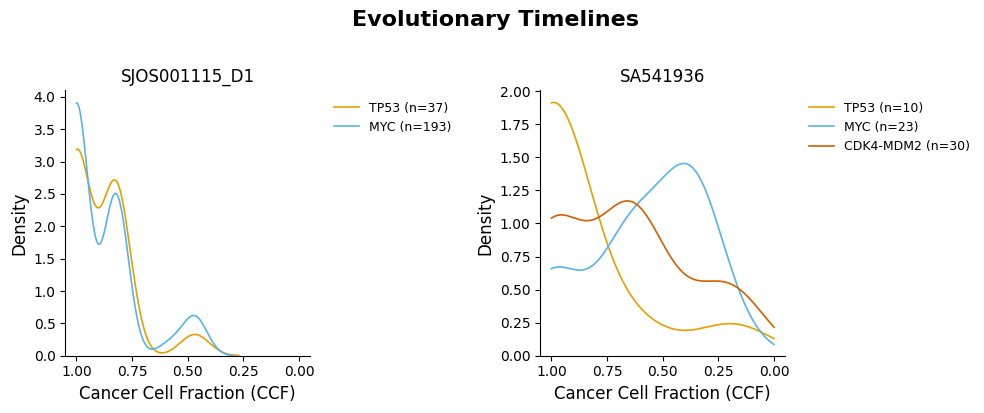

In [16]:
hotspot_order = ['TP53', 'MYC', 'CCND3', 'CCNE1', 'CDK4-MDM2']
okabe_ito_colors = ['#E69F00', '#56B4E9', '#009E73', '#0072B2', '#D55E00']
hotspot_palette = dict(zip(hotspot_order, okabe_ito_colors))

samples_to_plot = ['SJOS001115_D1', 'SA541936']

n_samples = len(samples_to_plot)
n_cols = min(2, n_samples)
n_rows = math.ceil(n_samples / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), squeeze=False)
axes = axes.flatten()

for i, sample in enumerate(samples_to_plot):
    ax = axes[i]

    plot_df = SVs_in_cSVs_df[SVs_in_cSVs_df['Sample_ID'] == sample]

    for event in hotspot_order:
        ccf = plot_df[plot_df['hotspot_event'] == event]['CCF'].dropna()
        if len(ccf) < 2:
            continue

        sns.kdeplot(
            x=ccf, ax=ax,
            fill=False,
            color=hotspot_palette[event],
            clip=(0, 1.0),
            linewidth=1.2,
            label=f"{event} (n={len(ccf)})"
        )

    ax.set_title(f'{sample}', fontsize=12)
    ax.set_xlim(1.05, -0.05)
    ax.set_xlabel('Cancer Cell Fraction (CCF)', fontsize=12)
    ax.set_ylabel('Density', fontsize=12)
    ax.spines[['right', 'top']].set_visible(False)

    if ax.get_legend_handles_labels()[0]:
        ax.legend(fontsize=9, bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

fig.suptitle('Evolutionary Timelines', fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('../../../Images/Figures/Subclonality_Evolution_Curves_Sample_specific.svg', format='svg', bbox_inches='tight')
plt.show()